In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
file_path = "../data/raw/House_Rent_10M_balanced_40cities.csv"
df = pd.read_csv(file_path)
df.head()

,Property ID,Building Type,Year Built,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,Th50000000,Apartment,1990,2022-04-20,2,15266,993,4 out of 12,Built Area,Area 870,Ghaziabad,Furnished,Bachelors,1,Contact Owner
1,Th50000001,Apartment,1996,2022-07-04,1,15066,823,8 out of 5,Built Area,Area 150,Meerut,Semi-Furnished,Bachelors,1,Contact Agent
2,Th50000002,Apartment,2015,2022-04-10,3,12474,727,9 out of 8,Carpet Area,Area 274,Vijayawada,Unfurnished,Family,3,Contact Owner
3,Th50000003,Apartment,2014,2022-05-25,2,11255,1072,5 out of 8,Plot Area,Area 987,Faridabad,Furnished,Bachelors,1,Contact Agent
4,Th50000004,Apartment,1993,2022-06-03,2,18937,1293,3 out of 12,Super Area,Area 655,Jodhpur,Semi-Furnished,Family,1,Contact Owner


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000000 entries, 0 to 9999999
Data columns (total 15 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   Property ID        object
 1   Building Type      object
 2   Year Built         int64 
 3   Posted On          object
 4   BHK                int64 
 5   Rent               int64 
 6   Size               int64 
 7   Floor              object
 8   Area Type          object
 9   Area Locality      object
 10  City               object
 11  Furnishing Status  object
 12  Tenant Preferred   object
 13  Bathroom           int64 
 14  Point of Contact   object
dtypes: int64(5), object(10)
memory usage: 1.1+ GB


In [4]:
df.isnull().sum()

Property ID          0
Building Type        0
Year Built           0
Posted On            0
BHK                  0
Rent                 0
Size                 0
Floor                0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
dtype: int64

In [5]:
df.describe()

,Year Built,BHK,Rent,Size,Bathroom
count,1.000000e+07,1.000000e+07,1.000000e+07,1.000000e+07,1.000000e+07
mean,2.005501e+03,1.999746e+00,1.953644e+04,1.562663e+03,1.999628e+00
std,9.232133e+00,1.053853e+00,1.614902e+04,1.107945e+03,8.164948e-01
min,1.990000e+03,1.000000e+00,7.500000e+02,1.500000e+02,1.000000e+00
25%,1.998000e+03,1.000000e+00,7.848000e+03,7.530000e+02,1.000000e+00
50%,2.005000e+03,2.000000e+00,1.510600e+04,1.273000e+03,2.000000e+00
75%,2.013000e+03,3.000000e+00,2.610200e+04,2.136000e+03,3.000000e+00
max,2.021000e+03,4.000000e+00,9.996600e+04,5.000000e+03,3.000000e+00


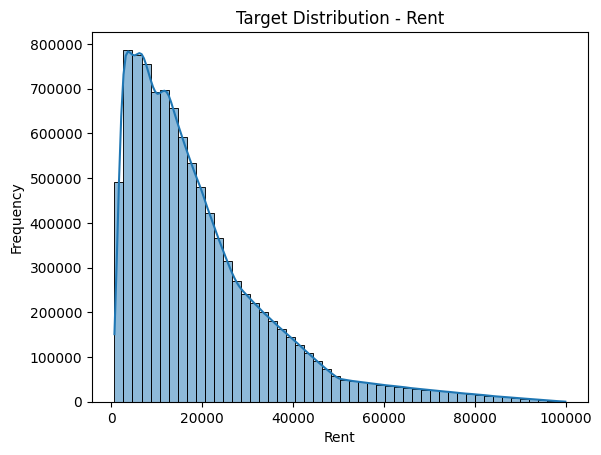

In [6]:
#Розподіл орендни
plt.figure()
sns.histplot(df["Rent"], bins=50, kde=True)
plt.title("Target Distribution - Rent")
plt.xlabel("Rent")
plt.ylabel("Frequency")
plt.show()

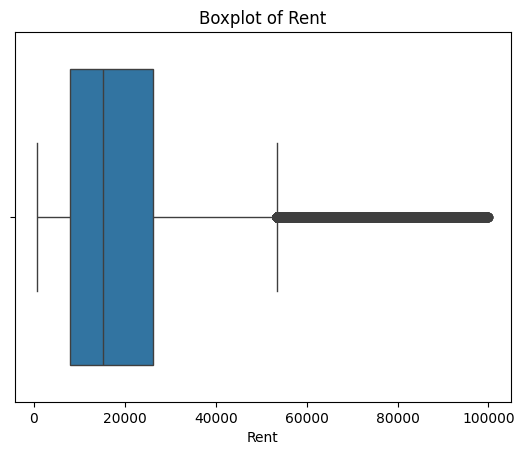

In [7]:
plt.figure()
sns.boxplot(x=df["Rent"])
plt.title("Boxplot of Rent")
plt.show()

In [8]:
numeric_df = df[['BHK', 'Rent', 'Size', 'Bathroom']]
correlation_matrix = numeric_df.corr()
correlation_matrix

,BHK,Rent,Size,Bathroom
BHK,1.000000,-0.021688,-0.025031,0.000283
Rent,-0.021688,1.000000,0.857978,-0.000426
Size,-0.025031,0.857978,1.000000,-0.000427
Bathroom,0.000283,-0.000426,-0.000427,1.000000


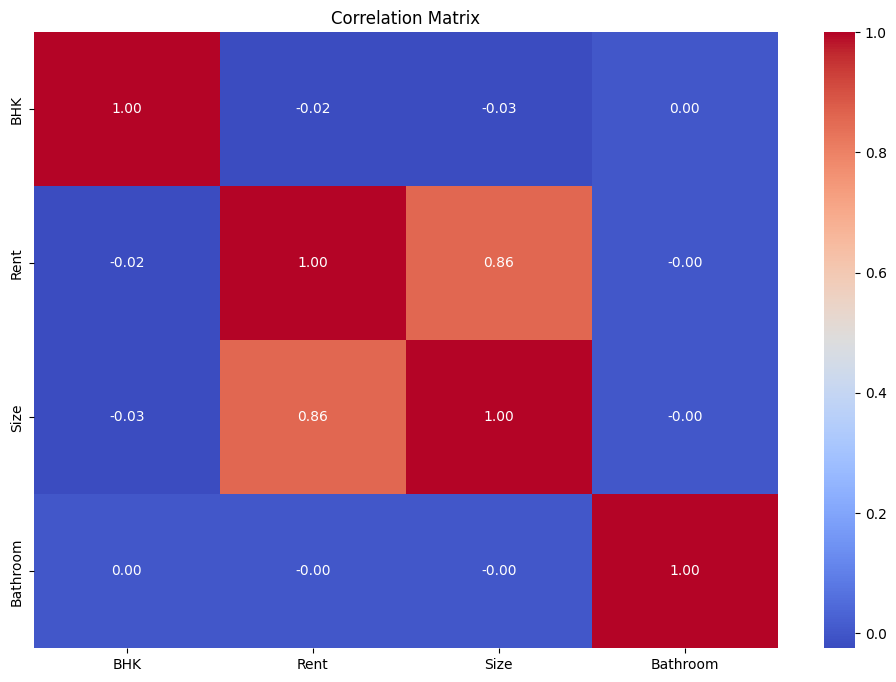

In [9]:
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [3]:
columns_to_check = [
    "Building Type",
    "Area Type",
    "Area Locality",
    "City",
    "Furnishing Status",
    "Tenant Preferred",
    "Point of Contact"
]

for col in columns_to_check:
    print(f"\n===== {col} =====")
    print(f"Number of unique values: {df[col].nunique()}")
    print(df[col].unique())


===== Building Type =====
Number of unique values: 6
['Apartment' 'Single Family' 'Condo' 'House' 'Office' 'Land']

===== Area Type =====
Number of unique values: 4
['Built Area' 'Carpet Area' 'Plot Area' 'Super Area']

===== Area Locality =====
Number of unique values: 900
['Area 870' 'Area 150' 'Area 274' 'Area 987' 'Area 655' 'Area 780'
 'Area 715' 'Area 747' 'Area 794' 'Area 653' 'Area 430' 'Area 718'
 'Area 542' 'Area 667' 'Area 758' 'Area 257' 'Area 830' 'Area 708'
 'Area 914' 'Area 835' 'Area 853' 'Area 210' 'Area 922' 'Area 345'
 'Area 155' 'Area 621' 'Area 386' 'Area 224' 'Area 862' 'Area 600'
 'Area 519' 'Area 534' 'Area 951' 'Area 492' 'Area 553' 'Area 135'
 'Area 162' 'Area 515' 'Area 435' 'Area 168' 'Area 335' 'Area 367'
 'Area 321' 'Area 949' 'Area 398' 'Area 570' 'Area 772' 'Area 820'
 'Area 201' 'Area 843' 'Area 279' 'Area 107' 'Area 919' 'Area 512'
 'Area 206' 'Area 480' 'Area 810' 'Area 906' 'Area 956' 'Area 798'
 'Area 119' 'Area 874' 'Area 759' 'Area 781' 'Area 110